# Neural Network (MLP): A Comprehensive Guide

A Neural Network (Multi-Layer Perceptron) is inspired by the human brain. It consists of layers of interconnected 'neurons' that learn to recognize patterns in data through a process called backpropagation.

In this notebook, we'll cover:
1. Basic concepts of Neural Networks
2. Data preparation and visualization
3. Building a neural network from scratch
4. Using scikit-learn's MLPClassifier
5. Model evaluation and interpretation

# Simple Explanation: What Does the Code Below Do?

Think of a neural network like a factory with multiple assembly lines (layers). Raw materials (input data) enter the first line. Each assembly line transforms the data and passes it to the next. At the end, the final product is a prediction.

At each 'neuron', two things happen:
1. **Weighted Sum**: Each input is multiplied by a weight and summed.
2. **Activation Function**: The sum is passed through a function (like ReLU or sigmoid) to introduce non-linearity.

Training happens via **Backpropagation** — the network calculates how wrong its predictions are and adjusts all weights to minimize the error.

Here's what the code does:
1. Implements a simple neural network from scratch with forward/backward propagation.
2. Uses scikit-learn's MLPClassifier on a real dataset.
3. Visualizes the training progress and decision boundaries.

In short: Neural networks learn by adjusting millions of small numbers (weights) until they make accurate predictions!

In [1]:
# Create a virtual environment and install required libraries
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed in the virtual environment.')
else:
    print('Could not find pip in the virtual environment. Please check your Python installation.')

Virtual environment already exists at ml_env
Required libraries installed in the virtual environment.


# 1. Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Generating Sample Data

We'll use two datasets:
1. The 'moons' dataset — a challenging non-linear classification problem.
2. This shows where neural networks really shine over simpler models.

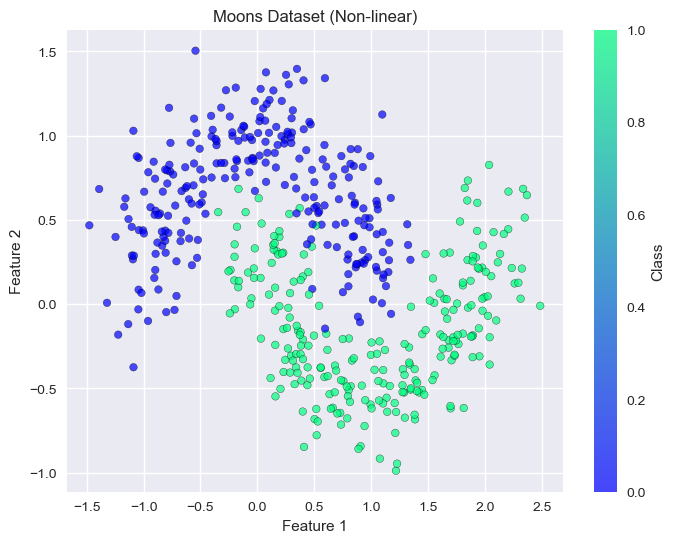

In [3]:
# Generate moons dataset
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', alpha=0.7, edgecolors='k', s=30)
plt.title('Moons Dataset (Non-linear)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')
plt.grid(True)
plt.show()

# 3. Implementing a Simple Neural Network from Scratch

Architecture: Input → Hidden Layer (sigmoid) → Output Layer (sigmoid)

Steps:
1. **Forward Pass**: Compute predictions.
2. **Loss**: Binary Cross-entropy.
3. **Backward Pass**: Compute gradients via chain rule.
4. **Update**: Adjust weights using gradient descent.

Neural Network (Scratch) Accuracy: 0.8600


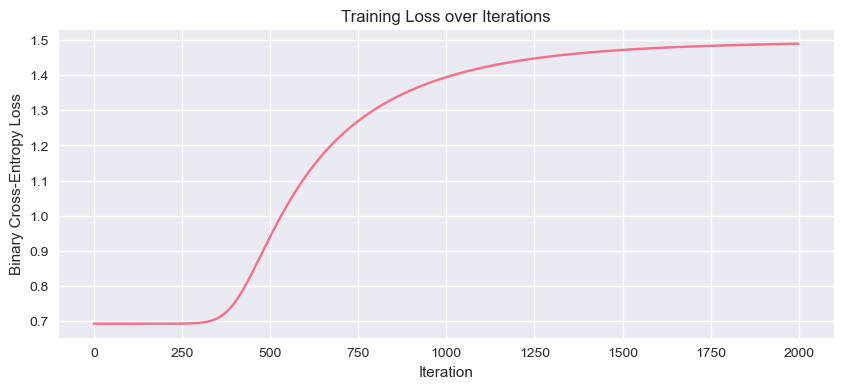

In [4]:
class SimpleNeuralNetwork:
    def __init__(self, hidden_size=16, learning_rate=0.01, n_iterations=1000):
        self.hidden_size = hidden_size
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.history = {'loss': []}

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def _sigmoid_deriv(self, a):
        return a * (1 - a)

    def _init_weights(self, n_input):
        np.random.seed(42)
        self.W1 = np.random.randn(n_input, self.hidden_size) * 0.01
        self.b1 = np.zeros((1, self.hidden_size))
        self.W2 = np.random.randn(self.hidden_size, 1) * 0.01
        self.b2 = np.zeros((1, 1))

    def _forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self._sigmoid(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self._sigmoid(self.z2)
        return self.a2

    def _backward(self, X, y):
        m = X.shape[0]
        y = y.reshape(-1, 1)

        # Output layer gradient
        delta2 = self.a2 - y
        dW2 = self.a1.T @ delta2 / m
        db2 = delta2.sum(axis=0, keepdims=True) / m

        # Hidden layer gradient
        delta1 = (delta2 @ self.W2.T) * self._sigmoid_deriv(self.a1)
        dW1 = X.T @ delta1 / m
        db1 = delta1.sum(axis=0, keepdims=True) / m

        # Update weights
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X, y):
        self._init_weights(X.shape[1])
        for i in range(self.n_iterations):
            a2 = self._forward(X)
            self._backward(X, y)
            eps = 1e-8
            loss = -np.mean(y * np.log(a2 + eps) + (1 - y) * np.log(1 - a2 + eps))
            self.history['loss'].append(loss)

    def predict(self, X, threshold=0.5):
        proba = self._forward(X)
        return (proba.flatten() >= threshold).astype(int)

nn_scratch = SimpleNeuralNetwork(hidden_size=16, learning_rate=0.1, n_iterations=2000)
nn_scratch.fit(X_train, y_train)
y_pred_scratch = nn_scratch.predict(X_test)

print(f'Neural Network (Scratch) Accuracy: {accuracy_score(y_test, y_pred_scratch):.4f}')

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(nn_scratch.history['loss'])
plt.xlabel('Iteration')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Training Loss over Iterations')
plt.grid(True)
plt.show()

# 4. Using Scikit-learn's MLPClassifier

Scikit-learn's MLPClassifier supports multiple hidden layers, different activation functions, and advanced optimizers like Adam.

In [5]:
# Compare different architectures
architectures = [
    (16,),
    (64,),
    (64, 32),
    (128, 64, 32)
]

results = []
for arch in architectures:
    mlp = MLPClassifier(hidden_layer_sizes=arch, max_iter=500, random_state=42, 
                        learning_rate_init=0.01, activation='relu')
    mlp.fit(X_train, y_train)
    acc = accuracy_score(y_test, mlp.predict(X_test))
    results.append({'Architecture': str(arch), 'Accuracy': acc})
    print(f'Architecture {str(arch):20s} → Test Accuracy: {acc:.4f}')

# Best model
best_arch = max(results, key=lambda x: x['Accuracy'])
print(f'\nBest Architecture: {best_arch["Architecture"]} → Acc: {best_arch["Accuracy"]:.4f}')

# Train best model
best_hidden = eval(best_arch['Architecture'])
best_mlp = MLPClassifier(hidden_layer_sizes=best_hidden, max_iter=500, random_state=42)
best_mlp.fit(X_train, y_train)
y_pred = best_mlp.predict(X_test)

print(f'\nClassification Report:\n{classification_report(y_test, y_pred)}')

Architecture (16,)                → Test Accuracy: 0.9800
Architecture (64,)                → Test Accuracy: 0.9800
Architecture (64, 32)             → Test Accuracy: 0.9700
Architecture (128, 64, 32)        → Test Accuracy: 0.9400

Best Architecture: (16,) → Acc: 0.9800

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.98      0.88        43
           1       0.98      0.82      0.90        57

    accuracy                           0.89       100
   macro avg       0.89      0.90      0.89       100
weighted avg       0.91      0.89      0.89       100



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# 5. Model Evaluation

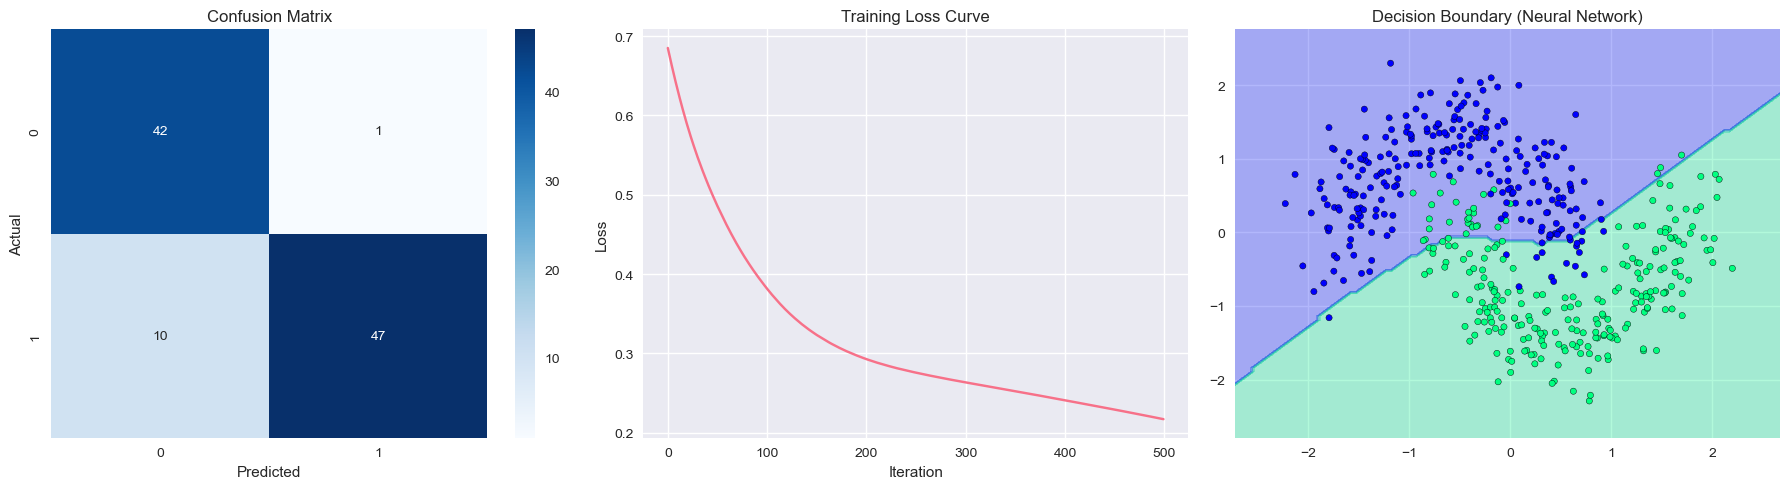


Key Insights:
- Neural Networks can learn complex non-linear boundaries.
- More layers/neurons increase capacity but can overfit.
- Always scale features before training neural networks!
- Use relu activation for hidden layers; sigmoid/softmax for output.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. Training Loss Curve
axes[1].plot(best_mlp.loss_curve_)
axes[1].set_title('Training Loss Curve')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss')
axes[1].grid(True)

# 3. Decision Boundary
h = 0.05
x_min, x_max = X_scaled[:, 0].min()-0.5, X_scaled[:, 0].max()+0.5
y_min, y_max = X_scaled[:, 1].min()-0.5, X_scaled[:, 1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = best_mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
axes[2].contourf(xx, yy, Z, alpha=0.3, cmap='winter')
axes[2].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='winter', edgecolors='k', s=20)
axes[2].set_title('Decision Boundary (Neural Network)')

plt.tight_layout()
plt.show()

print('\nKey Insights:')
print('- Neural Networks can learn complex non-linear boundaries.')
print('- More layers/neurons increase capacity but can overfit.')
print('- Always scale features before training neural networks!')
print('- Use relu activation for hidden layers; sigmoid/softmax for output.')

# Conclusions and Key Takeaways
Artificial Neural Networks (ANNs) are versatile and powerful algorithms loosely inspired by biological brains. They consist of input, hidden, and output layers of interconnected nodes (neurons).
- **Universal Approximators**: Given enough hidden neurons and layers, a neural network can theoretically approximate any continuous function.
- **Deep Learning**: Networks with multiple hidden layers can automatically learn hierarchical feature representations from raw data (e.g., edges -> shapes -> faces).
- **Data Hungry**: They require vast amounts of data to outperform traditional ML algorithms.

# Pros and Cons
**Pros:**
- State-of-the-art performance on unstructured data (images, text, audio).
- Eliminates the need for manual feature engineering in many domains (e.g., CNNs learning visual features automatically).
- Highly flexible architectures can solve complex multi-input, multi-output problems.

**Cons:**
- "Black Box" nature: extremely difficult to interpret exactly why a network made a specific prediction.
- Computationally highly expensive, often requiring GPUs/TPUs to train in a reasonable timeframe.
- Prone to massive overfitting if not properly regularized or provided with enough data.
- Requires extensive hyperparameter tuning (architecture, learning rate, batch size, etc.).

# 15 Interview Questions and Answers

1. **What is an Artificial Neuron (Perceptron)?**
   *Answer*: The basic unit of a neural network. It takes inputs, multiplies them by weights, adds a bias, and passes the sum through an activation function to produce an output.

2. **What is the role of an Activation Function?**
   *Answer*: It introduces non-linearity into the network. Without non-linear activation functions, a deep neural network, no matter how many layers it has, would just be a complex linear regression model.

3. **What is the Vanishing Gradient Problem?**
   *Answer*: During backpropagation, gradients are continually multiplied by the derivative of the activation function. If these derivatives are tiny (like in Sigmoid or Tanh), the gradient becomes exponentially small as it propagates backwards to earlier layers, preventing them from learning.

4. **How does ReLU solve the Vanishing Gradient Problem?**
   *Answer*: The Rectified Linear Unit (ReLU) activation function outputs `max(0, x)`. Its derivative is exactly 1 for all positive inputs, meaning the gradient doesn't shrink as it multiplies backward through the deeper layers of the network.

5. **What is Backpropagation?**
   *Answer*: The core algorithm for training neural networks. It calculates the gradient of the loss function with respect to every weight in the network by applying the chain rule of calculus backwards from the output layer to the input layer.

6. **What is the difference between Epoch, Batch Size, and Iteration?**
   *Answer*: Epoch: one complete forward and backward pass of ALL training examples. Batch Size: the number of training examples in one forward/backward pass. Iteration: number of batches needed to complete one epoch.

7. **What is Dropout?**
   *Answer*: A powerful regularization technique where randomly selected neurons are ignored ("dropped out") during training. This prevents units from co-adapting too much and forces the network to learn robust, redundant representations.

8. **Why do we need to initialize weights randomly?**
   *Answer*: If all weights are initialized to the same value (like zero), then every neuron in a layer will compute the exact same output, compute the exact same gradient during backprop, and update in the exact same way. Random initialization breaks this symmetry.

9. **What is the difference between Stochastic, Batch, and Mini-Batch Gradient Descent?**
   *Answer*: Batch averages the gradient over the entire dataset before taking a step. Stochastic takes a step after every single data point (noisy but fast). Mini-Batch is the compromise, taking a step after a small batch (e.g., 32 or 64 samples).

10. **What is Softmax?**
    *Answer*: An activation function usually used on the final output layer of a multi-class classification network. It converts a vector of raw scores (logits) into a probability distribution where the sum of all probabilities equals 1.

11. **Why is scaling/normalization crucial for Neural Networks?**
    *Answer*: If features are vastly different scales, the loss landscape becomes highly elongated. This pushes the weights to wildly different magnitudes, making gradient descent converge incredibly slowly, oscillate wildly, or get stuck in local minima.

12. **What is an Optimizer like Adam?**
    *Answer*: Adaptive Moment Estimation (Adam) is an optimizer that improves upon standard gradient descent by computing adaptive learning rates for each parameter. It uses both the exponentially decaying average of past gradients (momentum) and past squared gradients.

13. **What is the difference between CNNs, RNNs, and standard Feed-Forward networks?**
    *Answer*: Feed-forward are for standard tabular data. CNNs (Convolutional) use filters to capture spatial hierarchies, perfect for images. RNNs (Recurrent) have sequential memory, perfect for time-series or text.

14. **What does the 'Loss' or 'Cost' function represent?**
    *Answer*: It is a metric that quantifies how far off the neural network's predictions are from the true labels. The entire goal of training is to minimize this specific mathematical function.

15. **How do you determine the optimal number of hidden layers and neurons?**
    *Answer*: There is no strict mathematical formula; it's mostly empirical (trial and error). However, a common starting point is one hidden layer. More layers are added only if the model is underfitting the training data (assuming adequate training time).
